In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

# import local libraries
import src.utils.config as config
import proc.process_behavior_signals as pbs
# import proc.organize as org
import src.utils.data_io as dio
import src.utils.pdata_io as pdio
import numpy as np

# print(config.PROJECT_ROOT)
# print(config.RAW_BASE)
# print(config.PROC_BASE)

import sys
from pathlib import Path

CODE_BASE = Path(config.CODE_BASE).expanduser()
sys.path.append(str(CODE_BASE))

print("Added to path:", CODE_BASE)

# make the data dictionary which contains list of all animals and sessions and
# file names of videos h264 and mat files

data_root = config.RAW_BASE
cc_data = dio.build_classical_conditioning_dict(data_root)
pdata_root = config.PROC_BASE
# print(data_root)
# print(cc_data)
results = pbs.process_cc_data(
    cc_data,
    # animals={"NML_04"},
    phase="air_training",
    # dates={"2026_01_13"},
    # overwrite=True,
)


/home/nmldata2/ccaw/Python
Added to path: /home/nmldata2/ccaw/Python
[CACHE] NML_04 2026_01_12
[CACHE] NML_04 2026_01_13
[CACHE] NML_04 2026_01_14
[CACHE] NML_04 2026_01_15
[CACHE] NML_04 2026_01_16
[CACHE] NML_04 2026_01_17
[CACHE] NML_04 2026_01_18
[CACHE] NML_04 2026_01_20
[CACHE] NML_04 2026_01_21
[CACHE] NML_04 2026_01_22
[CACHE] NML_04 2026_01_23
[CACHE] NML_04 2026_01_24
[CACHE] NML_04 2026_01_25
[CACHE] NML_04 2026_01_26
[CACHE] NML_04 2026_01_27
[CACHE] NML_05 2026_01_12
[CACHE] NML_05 2026_01_13
[CACHE] NML_05 2026_01_14
[CACHE] NML_05 2026_01_15
[CACHE] NML_05 2026_01_16
[CACHE] NML_05 2026_01_17
[CACHE] NML_05 2026_01_18
[CACHE] NML_05 2026_01_20
[CACHE] NML_05 2026_01_21
[CACHE] NML_05 2026_01_22
[CACHE] NML_05 2026_01_23
[CACHE] NML_05 2026_01_24
[CACHE] NML_05 2026_01_25
[CACHE] NML_05 2026_01_26
[CACHE] NML_05 2026_01_27
[CACHE] NML_06 2026_01_12
[CACHE] NML_06 2026_01_13
[CACHE] NML_06 2026_01_14
[CACHE] NML_06 2026_01_15
[CACHE] NML_06 2026_01_16
[CACHE] NML_06 2026_0

In [2]:
import proc.ami as am

Trials: 58
Median forward cm: 9.613273519984768


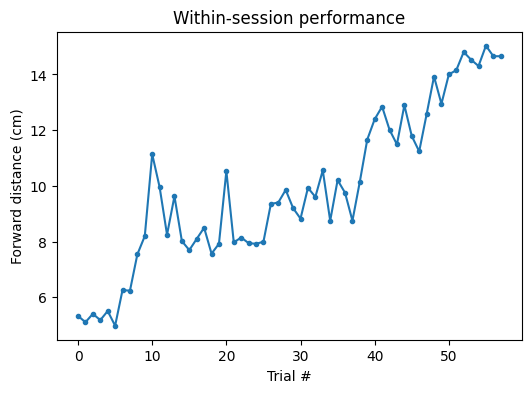

In [3]:
b = results["NML_04"]["2026_01_12"]
tt = am.build_trial_table(b)

print("Trials:", len(tt["forward_cm"]))
print("Median forward cm:", np.median(tt["forward_cm"]))
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(tt["forward_cm"], '.-')
plt.xlabel("Trial #")
plt.ylabel("Forward distance (cm)")
plt.title("Within-session performance")
plt.show()

In [33]:
print(b.keys())


dict_keys(['fs', 'si', 'number_of_samples', 't', 'tm', 'air_raw', 'air_bin', 'Air_r', 'Air_f', 'Air_edges_report', 'encoderCount', 'countsPerRev', 'dist_net_cm', 'dist_path_cm', 'speed_net_cms', 'speed_path_cms', 'speed_window_ms', 'bias', 'trial_forward_cm'])


In [30]:
import proc.behavior_metrics as bm

b = results["NML_04"]["2026_01_12"]

trial_df = bm.build_trial_table(b, drop_n=3)
summary = bm.summarize_session(b, trial_df)

print(summary)
trial_df.head()

{'n_trials': 55, 'median_forward_cm': 9.751503596742719, 'median_AMI': -0.09680554118369619, 'mean_AMI': 0.024317985778494377, 'median_latency_s': 0.4378, 'success_rate': 0.01818181818181818, 'cv_forward': 0.26370918617769945, 'frac_move_on': 0.20500449109833838, 'frac_move_off': 0.6274828420418054, 'mean_speed_on_time': 1.1728546928005361, 'mean_speed_off_time': 4.159076877103913, 'speed_ratio': 0.2819988009779782, 'stationary_off_frac': 0.3725171579581946}


,trial,forward_cm,duration_s,mean_speed_on,peak_speed_on,mean_speed_pre,AMI_speed,delta_speed,latency_s
0,3,5.177345,2.136398,2.175175,5.780530,0.404260,0.686551,1.770915,0.0000
1,4,5.504070,11.254601,0.281363,9.047787,4.382806,-0.879351,-4.101443,10.3854
2,5,4.976283,1.225197,4.085445,8.293805,7.418015,-0.289702,-3.332570,0.0000
3,6,6.258053,1.879807,3.115588,9.550442,0.013370,0.991454,3.102218,0.8464
4,7,6.232920,1.032196,6.048318,7.539822,6.017638,0.002543,0.030679,0.0000


In [ ]:
import vis.plot_ami as plt_ami

plt_ami.plot_ami_across_days(results, "NML_04")
plt_ami.plot_ami_across_days(results, "NML_05")
plt_ami.plot_ami_across_days(results, "NML_06")

In [24]:
b = results["NML_04"]["2026_01_12"]
print(b.keys())

dict_keys(['fs', 'si', 'number_of_samples', 't', 'tm', 'air_raw', 'air_bin', 'Air_r', 'Air_f', 'Air_edges_report', 'encoderCount', 'countsPerRev', 'dist_net_cm', 'dist_path_cm', 'speed_net_cms', 'speed_path_cms', 'speed_window_ms', 'bias', 'trial_forward_cm'])


In [38]:
session_df = bm.build_session_summary(results, speed_ratio_thr=1.0, ami_thr=0.3, off_frac_thr=0.6, speed_thresh=1.0)
session_df.head()

,animal,date,engaged,n_trials,median_forward_cm,median_AMI,mean_AMI,median_latency_s,success_rate,cv_forward,frac_move_on,frac_move_off,mean_speed_on_time,mean_speed_off_time,speed_ratio,stationary_off_frac
0,NML_04,2026_01_12,False,55,9.751504,-0.096806,0.024318,0.4378,0.018182,0.263709,0.205004,0.627483,1.172855,4.159077,0.281999,0.372517
1,NML_04,2026_01_13,False,52,5.566902,0.653856,0.362146,0.5059,0.000000,0.203025,0.165701,0.391252,0.478337,1.671397,0.286190,0.608748
2,NML_04,2026_01_14,False,56,32.835926,0.135467,0.197571,0.3213,0.928571,0.256942,0.419018,0.676138,2.740580,3.469536,0.789898,0.323862
3,NML_04,2026_01_15,False,57,34.984776,0.522788,0.509401,0.4392,0.807018,0.350703,0.634993,0.623220,4.465068,3.464345,1.288864,0.376780
4,NML_04,2026_01_16,False,61,11.661592,0.233533,0.310530,0.4660,0.229508,0.459208,0.548674,0.616034,2.378474,3.677689,0.646731,0.383966


In [39]:
best_sessions = (
    session_df
    .sort_values("speed_ratio", ascending=False)
    .groupby("animal")
    .head(1)
)
best_sessions

,animal,date,engaged,n_trials,median_forward_cm,median_AMI,mean_AMI,median_latency_s,success_rate,cv_forward,frac_move_on,frac_move_off,mean_speed_on_time,mean_speed_off_time,speed_ratio,stationary_off_frac
34,NML_06,2026_01_16,True,51,25.559998,0.985790,0.910077,0.1886,0.980392,0.165524,0.659129,0.133012,3.260556,0.215047,15.162029,0.866988
11,NML_04,2026_01_24,True,48,39.395572,0.989404,0.934528,0.2068,1.000000,0.298384,0.822702,0.186358,4.448277,0.454425,9.788811,0.813642
17,NML_05,2026_01_14,True,55,34.984776,0.994253,0.880126,0.2106,1.000000,0.023088,0.852646,0.198786,5.447059,0.750902,7.254026,0.801214


In [13]:
engaged_df = session_df[session_df["engaged"]]
engaged_df

,animal,date,engaged,mean_speed_on,mean_speed_off,speed_ratio,stationary_off_frac,mean_ami,n_trials


In [14]:
summary_counts = (
    session_df
    .groupby("animal")["engaged"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "n_engaged", "count": "n_total"})
)

summary_counts

,n_engaged,n_total
animal,,
NML_04,0,15
NML_05,0,15
NML_06,0,15


In [15]:
session_df.describe()

,mean_speed_on,mean_speed_off,speed_ratio,stationary_off_frac,mean_ami,n_trials
count,45.000000,45.000000,45.000000,45.000000,0.0,45.000000
mean,2.719990,1.609601,1.791723,0.626220,NaN,41.644444
std,1.941591,1.184352,7.724678,0.169129,NaN,18.549878
min,-0.519955,-0.109062,-43.813570,0.323862,NaN,3.000000
25%,0.656255,0.750902,0.363834,0.460536,NaN,24.000000
50%,3.010800,1.243721,1.260804,0.666245,NaN,51.000000
75%,4.448277,2.231289,3.809520,0.766304,NaN,54.000000
max,5.621603,4.159077,15.162029,0.886583,NaN,66.000000


In [16]:
session_df[[
    "speed_ratio",
    "mean_ami",
    "stationary_off_frac"
]].describe()

,speed_ratio,mean_ami,stationary_off_frac
count,45.000000,0.0,45.000000
mean,1.791723,NaN,0.626220
std,7.724678,NaN,0.169129
min,-43.813570,NaN,0.323862
25%,0.363834,NaN,0.460536
50%,1.260804,NaN,0.666245
75%,3.809520,NaN,0.766304
max,15.162029,NaN,0.886583
